In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import sys
import shutil
import sqlite3
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

np.random.seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Kaggle Source Path ─────────────────────────────────
KAGGLE_PATH = "D:/chest_xray/chest_xray"

# ── Valid Image Extensions ─────────────────────────────
VALID_EXT   = ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG')

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
RANDOM_SEED = 42

# ── Verify paths exist ─────────────────────────────────
print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ BASE        : {BASE}")
print(f"✅ IMG_DIR     : {IMG_DIR}")
print(f"✅ KAGGLE_PATH : {KAGGLE_PATH}")
print(f"✅ PLOTS       : {PLOTS}")
print(f"✅ RESULTS     : {RESULTS}")
print()

# Verify Kaggle path exists
if os.path.exists(KAGGLE_PATH):
    print(f"✅ Kaggle dataset found")
else:
    print(f"❌ Kaggle path not found: {KAGGLE_PATH}")
    print(f"   Please check the path!")

print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: SETUP COMPLETE
✅ BASE        : D:/Projects/Harsh_Mini_Project/medical_xray_project
✅ IMG_DIR     : D:/Projects/Harsh_Mini_Project/medical_xray_project/data/images
✅ KAGGLE_PATH : D:/chest_xray/chest_xray
✅ PLOTS       : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots
✅ RESULTS     : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results

✅ Kaggle dataset found
✅ Cell 0 complete - Ready to proceed


In [2]:
# Cell 1: Scan all images from Kaggle dataset

print("=" * 50)
print("   CELL 1: SCANNING KAGGLE IMAGES")
print("=" * 50)

# Define which folders to scan
# We skip val/ because it only has 16 images total
folders_to_scan = [
    ("train", "NORMAL",    0),
    ("train", "PNEUMONIA", 1),
    ("test",  "NORMAL",    0),
    ("test",  "PNEUMONIA", 1),
]

all_records = []

for split, label_name, label in folders_to_scan:
    folder_path = f"{KAGGLE_PATH}/{split}/{label_name}"
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        continue
    
    # Get all image files
    files = [f for f in os.listdir(folder_path)
             if f.endswith(VALID_EXT)]
    
    for fname in files:
        full_path = os.path.join(folder_path, fname)
        all_records.append({
            'original_path' : full_path,
            'original_name' : fname,
            'split'         : split,
            'label'         : label,
            'label_name'    : label_name,
        })
    
    print(f"✅ {split:5s}/{label_name:10s} : {len(files):>5} images found")

print()
print(f"{'─'*50}")
print(f"✅ Total images scanned : {len(all_records):,}")
print()

# Quick breakdown
df_scan = pd.DataFrame(all_records)
print("   Class Distribution:")
class_counts = df_scan['label_name'].value_counts()
for cls, cnt in class_counts.items():
    pct = cnt / len(df_scan) * 100
    print(f"   {cls:12s} : {cnt:>5} ({pct:.1f}%)")

print("=" * 50)
print("✅ Cell 1 complete")

   CELL 1: SCANNING KAGGLE IMAGES
✅ train/NORMAL     :  1341 images found
✅ train/PNEUMONIA  :  3875 images found
✅ test /NORMAL     :   234 images found
✅ test /PNEUMONIA  :   390 images found

──────────────────────────────────────────────────
✅ Total images scanned : 5,840

   Class Distribution:
   PNEUMONIA    :  4265 (73.0%)
   NORMAL       :  1575 (27.0%)
✅ Cell 1 complete


In [3]:
# Cell 2: Copy all images to project images folder

print("=" * 50)
print("   CELL 2: COPYING IMAGES TO PROJECT")
print("=" * 50)
print(f"Source : {KAGGLE_PATH}")
print(f"Target : {IMG_DIR}")
print(f"Total  : {len(all_records):,} images")
print(f"⏳ Please wait, this takes 3-8 minutes...")
print()

copied      = 0
skipped     = 0
failed      = 0
new_names   = []

for i, record in enumerate(all_records):
    # Create new filename to avoid conflicts
    # Format: split_LABEL_originalname
    # Example: train_NORMAL_IM-0001-0001.jpeg
    new_name = f"{record['split']}_{record['label_name']}_{record['original_name']}"
    new_path = os.path.join(IMG_DIR, new_name)
    
    # Store new name for later use
    new_names.append(new_name)
    
    # Skip if already copied (allows re-running cell)
    if os.path.exists(new_path):
        skipped += 1
        continue
    
    # Copy the file
    try:
        shutil.copy2(record['original_path'], new_path)
        copied += 1
    except Exception as e:
        print(f"❌ Failed: {record['original_name']} → {e}")
        failed += 1
    
    # Progress update every 500 images
    if (i + 1) % 500 == 0:
        print(f"   Progress: {i+1:,} / {len(all_records):,} images done...")

# Add new names to our records
for i, record in enumerate(all_records):
    record['image_index'] = new_names[i]

print()
print(f"✅ Copied  : {copied:,} images")
if skipped > 0:
    print(f"✅ Skipped : {skipped:,} (already existed)")
if failed > 0:
    print(f"❌ Failed  : {failed:,} images")

# Verify count in destination folder
actual_count = len([f for f in os.listdir(IMG_DIR)
                    if f.endswith(VALID_EXT)])
print(f"✅ Verified: {actual_count:,} images now in project folder")
print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: COPYING IMAGES TO PROJECT
Source : D:/chest_xray/chest_xray
Target : D:/Projects/Harsh_Mini_Project/medical_xray_project/data/images
Total  : 5,840 images
⏳ Please wait, this takes 3-8 minutes...

   Progress: 500 / 5,840 images done...
   Progress: 1,000 / 5,840 images done...
   Progress: 1,500 / 5,840 images done...
   Progress: 2,000 / 5,840 images done...
   Progress: 2,500 / 5,840 images done...
   Progress: 3,000 / 5,840 images done...
   Progress: 3,500 / 5,840 images done...
   Progress: 4,000 / 5,840 images done...
   Progress: 4,500 / 5,840 images done...
   Progress: 5,000 / 5,840 images done...
   Progress: 5,500 / 5,840 images done...

✅ Copied  : 5,840 images
✅ Verified: 5,840 images now in project folder
✅ Cell 2 complete


In [4]:
# Cell 3: Build base metadata DataFrame

print("=" * 50)
print("   CELL 3: BUILDING METADATA DATAFRAME")
print("=" * 50)

# Build DataFrame from our scanned records
df = pd.DataFrame(all_records)

# Keep only needed columns
df = df[['image_index', 'label', 'label_name']].copy()

# Verify
print(f"✅ Total rows    : {len(df):,}")
print(f"✅ Total columns : {len(df.columns)}")
print()
print("   Columns:", df.columns.tolist())
print()
print("   Class Distribution:")
for cls in ['NORMAL', 'PNEUMONIA']:
    cnt = len(df[df['label_name'] == cls])
    pct = cnt / len(df) * 100
    print(f"   {cls:12s} : {cnt:>5,} ({pct:.1f}%)")

print()
print("   First 5 rows:")
print(df.head())
print()
print("   Last 5 rows:")
print(df.tail())

print("=" * 50)
print("✅ Cell 3 complete")

   CELL 3: BUILDING METADATA DATAFRAME
✅ Total rows    : 5,840
✅ Total columns : 3

   Columns: ['image_index', 'label', 'label_name']

   Class Distribution:
   NORMAL       : 1,575 (27.0%)
   PNEUMONIA    : 4,265 (73.0%)

   First 5 rows:
                      image_index  label label_name
0  train_NORMAL_IM-0115-0001.jpeg      0     NORMAL
1  train_NORMAL_IM-0117-0001.jpeg      0     NORMAL
2  train_NORMAL_IM-0119-0001.jpeg      0     NORMAL
3  train_NORMAL_IM-0122-0001.jpeg      0     NORMAL
4  train_NORMAL_IM-0125-0001.jpeg      0     NORMAL

   Last 5 rows:
                                    image_index  label label_name
5835  test_PNEUMONIA_person96_bacteria_465.jpeg      1  PNEUMONIA
5836  test_PNEUMONIA_person96_bacteria_466.jpeg      1  PNEUMONIA
5837  test_PNEUMONIA_person97_bacteria_468.jpeg      1  PNEUMONIA
5838  test_PNEUMONIA_person99_bacteria_473.jpeg      1  PNEUMONIA
5839  test_PNEUMONIA_person99_bacteria_474.jpeg      1  PNEUMONIA
✅ Cell 3 complete


In [5]:
# Cell 4: Generate synthetic demographic metadata

print("=" * 50)
print("   CELL 4: GENERATING SYNTHETIC METADATA")
print("=" * 50)

np.random.seed(42)
n = len(df)

# ── Patient ID ─────────────────────────────────────────
df['patient_id'] = range(1, n + 1)

# ── Patient Age ────────────────────────────────────────
# Weighted distribution - more middle-aged patients
# Age groups: child(1-17), young(18-30), 
#             middle(31-60), senior(61-90)
age_groups_prob = [0.10, 0.20, 0.45, 0.25]
age_ranges      = [(1,17), (18,30), (31,60), (61,90)]

ages = []
for _ in range(n):
    # Pick age group based on probability
    group_idx = np.random.choice(4, p=age_groups_prob)
    low, high = age_ranges[group_idx]
    age       = np.random.randint(low, high + 1)
    ages.append(age)

df['age'] = ages

# ── Patient Gender ─────────────────────────────────────
# 55% Male, 45% Female
df['gender'] = np.random.choice(
    ['M', 'F'],
    size    = n,
    p       = [0.55, 0.45]
)

# ── View Position ──────────────────────────────────────
# 70% PA (front), 30% AP (back)
df['view_position'] = np.random.choice(
    ['PA', 'AP'],
    size = n,
    p    = [0.70, 0.30]
)

# ── Age Group Categories ───────────────────────────────
def assign_age_group(age):
    if age <= 30:
        return 'Young'
    elif age <= 60:
        return 'Middle'
    else:
        return 'Old'

df['age_group'] = df['age'].apply(assign_age_group)

# ── Print Summary ──────────────────────────────────────
print(f"✅ Patient ID    : 1 to {n:,}")
print()
print(f"   Age Statistics:")
print(f"   Min : {df['age'].min()}")
print(f"   Max : {df['age'].max()}")
print(f"   Mean: {df['age'].mean():.1f}")
print()
print(f"   Gender Distribution:")
gender_counts = df['gender'].value_counts()
for g, cnt in gender_counts.items():
    pct = cnt / n * 100
    label = 'Male' if g == 'M' else 'Female'
    print(f"   {label:8s} ({g}) : {cnt:,} ({pct:.1f}%)")
print()
print(f"   Age Group Distribution:")
age_grp_counts = df['age_group'].value_counts()
for grp, cnt in age_grp_counts.items():
    pct = cnt / n * 100
    print(f"   {grp:8s} : {cnt:,} ({pct:.1f}%)")
print()
print(f"   View Position Distribution:")
view_counts = df['view_position'].value_counts()
for v, cnt in view_counts.items():
    pct = cnt / n * 100
    print(f"   {v:8s} : {cnt:,} ({pct:.1f}%)")
print()
print(f"✅ Total columns now : {len(df.columns)}")
print(f"   Columns: {df.columns.tolist()}")
print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: GENERATING SYNTHETIC METADATA
✅ Patient ID    : 1 to 5,840

   Age Statistics:
   Min : 1
   Max : 90
   Mean: 44.7

   Gender Distribution:
   Male     (M) : 3,201 (54.8%)
   Female   (F) : 2,639 (45.2%)

   Age Group Distribution:
   Middle   : 2,614 (44.8%)
   Young    : 1,797 (30.8%)
   Old      : 1,429 (24.5%)

   View Position Distribution:
   PA       : 4,134 (70.8%)
   AP       : 1,706 (29.2%)

✅ Total columns now : 8
   Columns: ['image_index', 'label', 'label_name', 'patient_id', 'age', 'gender', 'view_position', 'age_group']
✅ Cell 4 complete


   CELL 5: CLASS DISTRIBUTION CHART


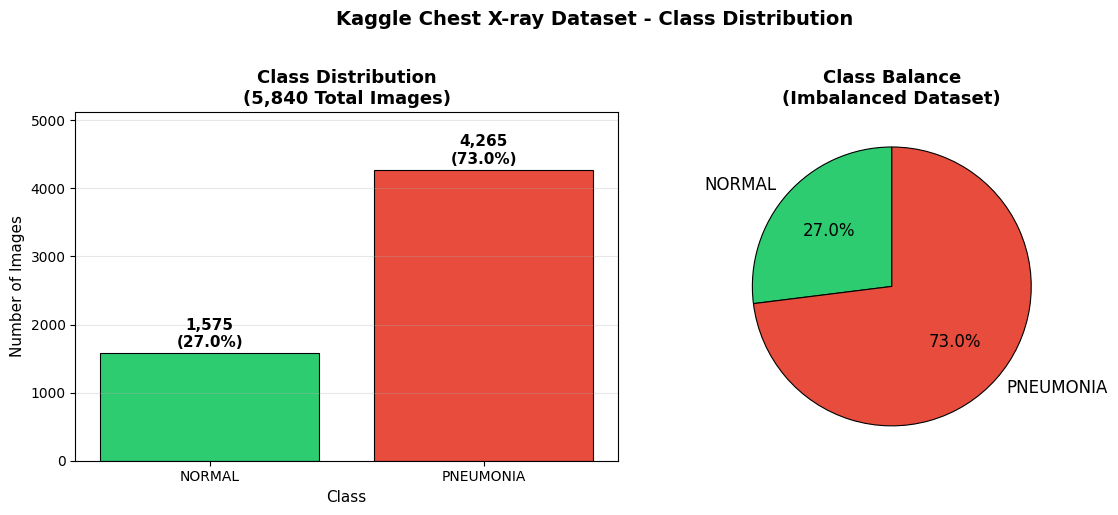

✅ NORMAL    : 1,575 images (27.0%)
✅ PNEUMONIA : 4,265 images (73.0%)
✅ Imbalance ratio : 1 : 2.7
✅ Plot saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/class_distribution.png
✅ Cell 5 complete


In [6]:
# Cell 5: Visualize class distribution

print("=" * 50)
print("   CELL 5: CLASS DISTRIBUTION CHART")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Chart 1: Class Distribution Bar Chart ─────────────
classes = ['NORMAL', 'PNEUMONIA']
counts  = [len(df[df['label_name'] == c]) for c in classes]
colors  = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(classes, counts, color=colors,
                   edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution\n(5,840 Total Images)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_xlabel('Class', fontsize=11)

# Add count labels on bars
for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Pie Chart ─────────────────────────────────
axes[1].pie(
    counts,
    labels      = classes,
    colors      = colors,
    autopct     = '%1.1f%%',
    startangle  = 90,
    textprops   = {'fontsize': 12},
    wedgeprops  = {'edgecolor': 'black', 'linewidth': 0.8}
)
axes[1].set_title('Class Balance\n(Imbalanced Dataset)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Kaggle Chest X-ray Dataset - Class Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save plot
save_path = f"{PLOTS}/class_distribution.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ NORMAL    : {counts[0]:,} images (27.0%)")
print(f"✅ PNEUMONIA : {counts[1]:,} images (73.0%)")
print(f"✅ Imbalance ratio : 1 : {counts[1]/counts[0]:.1f}")
print(f"✅ Plot saved : {save_path}")
print("=" * 50)
print("✅ Cell 5 complete")

   CELL 6: DEMOGRAPHIC DISTRIBUTION CHARTS


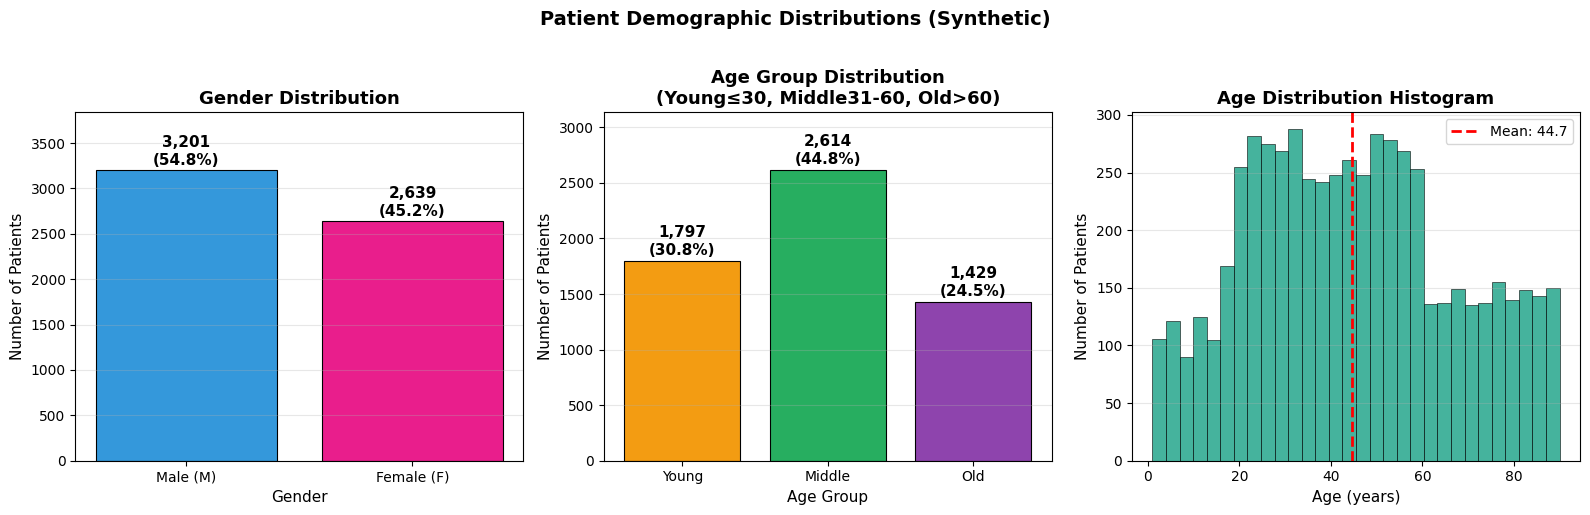

✅ Gender chart    : Male=3,201, Female=2,639
✅ Age group chart : Young=1,797, Middle=2,614, Old=1,429
✅ Age histogram   : Mean age = 44.7 years
✅ Plot saved      : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/demographic_distribution.png
✅ Cell 6 complete


In [7]:
# Cell 6: Visualize gender and age distributions

print("=" * 50)
print("   CELL 6: DEMOGRAPHIC DISTRIBUTION CHARTS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Chart 1: Gender Distribution ──────────────────────
gender_counts = df['gender'].value_counts()
gender_labels = ['Male (M)', 'Female (F)']
gender_values = [gender_counts.get('M', 0),
                 gender_counts.get('F', 0)]
gender_colors = ['#3498db', '#e91e8c']

bars = axes[0].bar(gender_labels, gender_values,
                   color=gender_colors,
                   edgecolor='black', linewidth=0.8)
axes[0].set_title('Gender Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_xlabel('Gender', fontsize=11)

for bar, val in zip(bars, gender_values):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, max(gender_values) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Age Group Distribution ───────────────────
age_order  = ['Young', 'Middle', 'Old']
age_counts = [len(df[df['age_group'] == g])
              for g in age_order]
age_colors = ['#f39c12', '#27ae60', '#8e44ad']

bars2 = axes[1].bar(age_order, age_counts,
                    color=age_colors,
                    edgecolor='black', linewidth=0.8)
axes[1].set_title('Age Group Distribution\n(Young≤30, Middle31-60, Old>60)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients', fontsize=11)
axes[1].set_xlabel('Age Group', fontsize=11)

for bar, val in zip(bars2, age_counts):
    pct = val / len(df) * 100
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[1].set_ylim(0, max(age_counts) * 1.2)
axes[1].grid(axis='y', alpha=0.3)

# ── Chart 3: Age Histogram ─────────────────────────────
axes[2].hist(df['age'], bins=30, color='#16a085',
             edgecolor='black', linewidth=0.5, alpha=0.8)
axes[2].set_title('Age Distribution Histogram',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Patients', fontsize=11)
axes[2].set_xlabel('Age (years)', fontsize=11)
axes[2].axvline(df['age'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"Mean: {df['age'].mean():.1f}")
axes[2].legend(fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Patient Demographic Distributions (Synthetic)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save plot
save_path = f"{PLOTS}/demographic_distribution.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Gender chart    : Male={gender_values[0]:,}, "
      f"Female={gender_values[1]:,}")
print(f"✅ Age group chart : Young={age_counts[0]:,}, "
      f"Middle={age_counts[1]:,}, Old={age_counts[2]:,}")
print(f"✅ Age histogram   : Mean age = {df['age'].mean():.1f} years")
print(f"✅ Plot saved      : {save_path}")
print("=" * 50)
print("✅ Cell 6 complete")

   CELL 7: SAMPLE X-RAY IMAGES


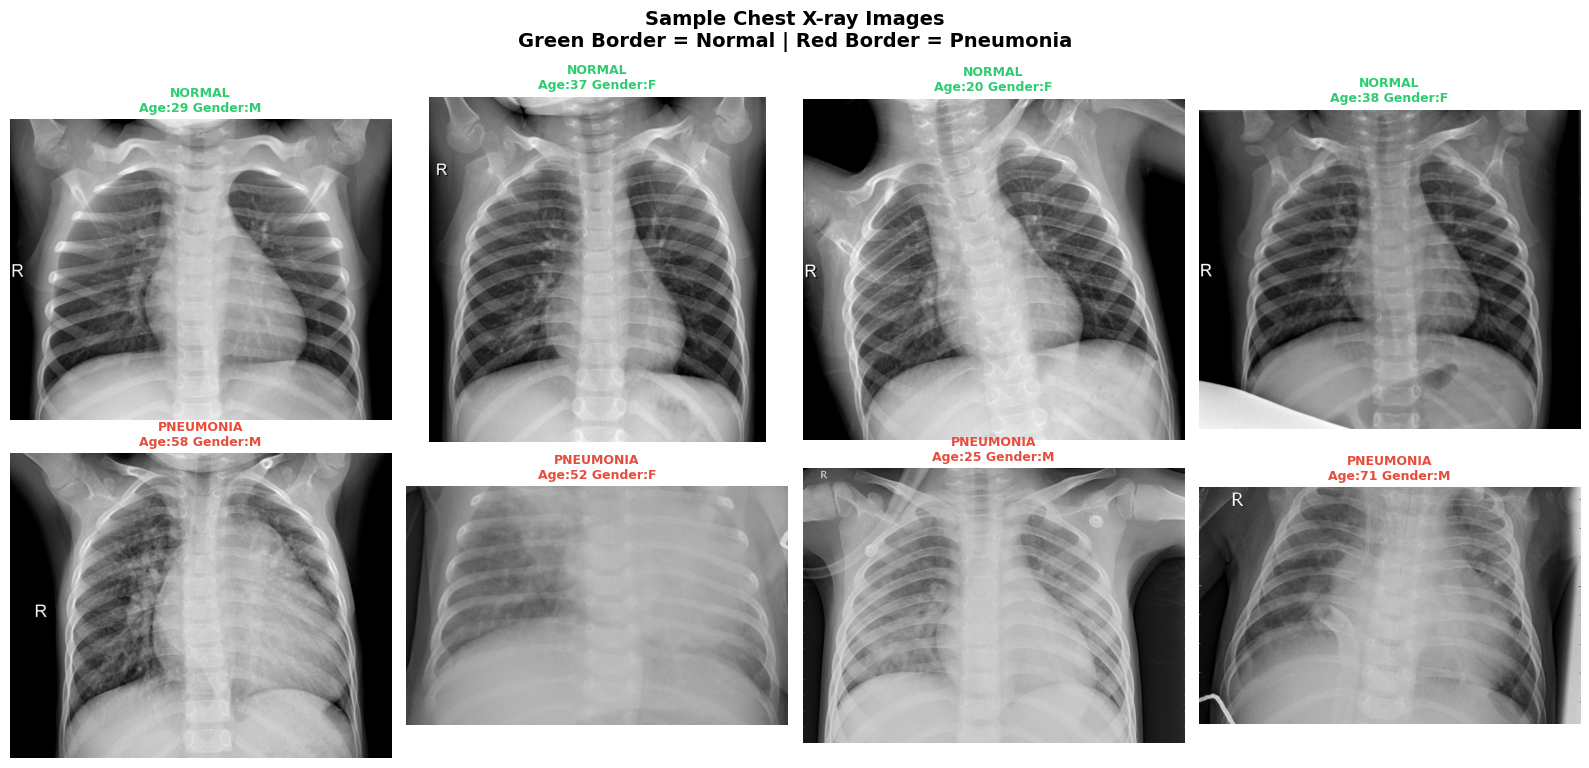

✅ Displayed 4 NORMAL images
✅ Displayed 4 PNEUMONIA images
✅ Plot saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/sample_xrays.png

   Visual difference to notice:
   NORMAL    → Clear lung fields, no opacity
   PNEUMONIA → White patches, cloudy areas
✅ Cell 7 complete


In [8]:
# Cell 7: Display sample X-ray images from dataset

print("=" * 50)
print("   CELL 7: SAMPLE X-RAY IMAGES")
print("=" * 50)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# ── Get 4 NORMAL and 4 PNEUMONIA samples ──────────────
normal_samples    = df[df['label_name'] == 'NORMAL'
                       ].sample(4, random_state=42)
pneumonia_samples = df[df['label_name'] == 'PNEUMONIA'
                       ].sample(4, random_state=42)

samples = [
    (normal_samples,    'NORMAL',    '#2ecc71', 0),
    (pneumonia_samples, 'PNEUMONIA', '#e74c3c', 1),
]

for sample_df, class_name, color, row in samples:
    for col, (_, row_data) in enumerate(
            sample_df.iterrows()):

        img_path = f"{IMG_DIR}/{row_data['image_index']}"
        ax       = axes[row][col]

        # Load image with OpenCV
        img = cv2.imread(img_path)

        if img is None:
            ax.text(0.5, 0.5, 'Image\nNot Found',
                    ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)
            ax.set_facecolor('#ffcccc')
        else:
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img, cmap='gray')

        # Title with patient info
        ax.set_title(
            f"{class_name}\n"
            f"Age:{row_data['age']} "
            f"Gender:{row_data['gender']}",
            fontsize=9,
            color=color,
            fontweight='bold'
        )
        ax.axis('off')

        # Add colored border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

# Row labels
axes[0][0].set_ylabel('NORMAL',    fontsize=12,
                       fontweight='bold', color='#2ecc71')
axes[1][0].set_ylabel('PNEUMONIA', fontsize=12,
                       fontweight='bold', color='#e74c3c')

plt.suptitle('Sample Chest X-ray Images\n'
             'Green Border = Normal | Red Border = Pneumonia',
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save plot
save_path = f"{PLOTS}/sample_xrays.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Displayed 4 NORMAL images")
print(f"✅ Displayed 4 PNEUMONIA images")
print(f"✅ Plot saved : {save_path}")
print()
print("   Visual difference to notice:")
print("   NORMAL    → Clear lung fields, no opacity")
print("   PNEUMONIA → White patches, cloudy areas")
print("=" * 50)
print("✅ Cell 7 complete")

In [9]:
# Cell 8: Create stratified train/val/test splits

from sklearn.model_selection import train_test_split

print("=" * 50)
print("   CELL 8: CREATING DATA SPLITS")
print("=" * 50)
print("   Strategy : Stratified split")
print("   Train    : 70%")
print("   Val      : 15%")
print("   Test     : 15%")
print("   Seed     : 42")
print()

# ── Step 1: Split off Test (15%) ───────────────────────
df_train_val, df_test = train_test_split(
    df,
    test_size    = 0.15,
    stratify     = df['label'],
    random_state = 42
)

# ── Step 2: Split Train/Val from remaining 85% ─────────
# 15/85 = 0.1765 gives us 15% of total for val
df_train, df_val = train_test_split(
    df_train_val,
    test_size    = 0.1765,
    stratify     = df_train_val['label'],
    random_state = 42
)

# ── Add split column to each ───────────────────────────
df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

# ── Print Summary ──────────────────────────────────────
total = len(df)
for name, subset in [('Train', df_train),
                     ('Val',   df_val),
                     ('Test',  df_test)]:
    n_total  = len(subset)
    n_normal = len(subset[subset['label'] == 0])
    n_pneumo = len(subset[subset['label'] == 1])
    pct      = n_total / total * 100
    print(f"   {name:6s} : {n_total:>5,} rows "
          f"({pct:.1f}%) │ "
          f"Normal={n_normal:,} "
          f"Pneumonia={n_pneumo:,}")

print()
print(f"   Total    : {len(df_train)+len(df_val)+len(df_test):,} rows")
print()

# ── Verify stratification ──────────────────────────────
print("   Pneumonia ratio per split (should be ~73%):")
for name, subset in [('Train', df_train),
                     ('Val',   df_val),
                     ('Test',  df_test)]:
    ratio = len(subset[subset['label']==1]) / len(subset) * 100
    print(f"   {name:6s} : {ratio:.1f}%")

print("=" * 50)
print("✅ Cell 8 complete")

   CELL 8: CREATING DATA SPLITS
   Strategy : Stratified split
   Train    : 70%
   Val      : 15%
   Test     : 15%
   Seed     : 42

   Train  : 4,087 rows (70.0%) │ Normal=1,102 Pneumonia=2,985
   Val    :   877 rows (15.0%) │ Normal=237 Pneumonia=640
   Test   :   876 rows (15.0%) │ Normal=236 Pneumonia=640

   Total    : 5,840 rows

   Pneumonia ratio per split (should be ~73%):
   Train  : 73.0%
   Val    : 73.0%
   Test   : 73.1%
✅ Cell 8 complete


In [10]:
# Cell 9: Save all CSV files to project folder

print("=" * 50)
print("   CELL 9: SAVING CSV FILES")
print("=" * 50)

# ── 1. Save complete metadata CSV ─────────────────────
# Add split column to full df first
df_full = pd.concat([df_train, df_val, df_test],
                     ignore_index=True)

metadata_path = f"{RESULTS}/processed_metadata.csv"
df_full.to_csv(metadata_path, index=False,
               encoding='utf-8')
print(f"✅ processed_metadata.csv : {len(df_full):,} rows")

# ── 2. Save train CSV ──────────────────────────────────
train_path = f"{RESULTS}/train.csv"
df_train.to_csv(train_path, index=False,
                encoding='utf-8')
print(f"✅ train.csv              : {len(df_train):,} rows")

# ── 3. Save val CSV ────────────────────────────────────
val_path = f"{RESULTS}/val.csv"
df_val.to_csv(val_path, index=False,
              encoding='utf-8')
print(f"✅ val.csv                : {len(df_val):,} rows")

# ── 4. Save test CSV ───────────────────────────────────
test_path = f"{RESULTS}/test.csv"
df_test.to_csv(test_path, index=False,
               encoding='utf-8')
print(f"✅ test.csv               : {len(df_test):,} rows")

print()

# ── Verify all files exist ─────────────────────────────
print("   Verifying saved files:")
csv_files = {
    'processed_metadata.csv' : metadata_path,
    'train.csv'              : train_path,
    'val.csv'                : val_path,
    'test.csv'               : test_path,
}

all_saved = True
for fname, fpath in csv_files.items():
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"   ✅ {fname:28s} {size_kb:.1f} KB")
    else:
        print(f"   ❌ {fname} NOT FOUND!")
        all_saved = False

print()

# ── Print column names ─────────────────────────────────
print("   Columns in all CSV files:")
for col in df_full.columns.tolist():
    print(f"   • {col}")

print()
print(f"   Save location: {RESULTS}")
print("=" * 50)
if all_saved:
    print("✅ Cell 9 complete - All 4 CSV files saved!")
else:
    print("❌ Some files missing - check paths!")

   CELL 9: SAVING CSV FILES
✅ processed_metadata.csv : 5,840 rows
✅ train.csv              : 4,087 rows
✅ val.csv                : 877 rows
✅ test.csv               : 876 rows

   Verifying saved files:
   ✅ processed_metadata.csv       445.8 KB
   ✅ train.csv                    313.7 KB
   ✅ val.csv                      65.7 KB
   ✅ test.csv                     66.5 KB

   Columns in all CSV files:
   • image_index
   • label
   • label_name
   • patient_id
   • age
   • gender
   • view_position
   • age_group
   • split

   Save location: D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results
✅ Cell 9 complete - All 4 CSV files saved!
